In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/london_listings_engineered.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.81,4.87,4.78,4.78,False,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.88,4.84,4.93,4.74,False,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.72,4.89,4.61,False,2,2,0,0,0.32
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,4.90,4.93,4.60,4.65,False,1,1,0,0,0.53
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,4.62,4.46,4.85,4.54,True,2,2,0,0,0.09


In [2]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (96871, 76)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            96871 non-null  int64  
 1   listing_url                                   96871 non-null  object 
 2   scrape_id                                     96871 non-null  int64  
 3   last_scraped                                  96871 non-null  object 
 4   source                                        96871 non-null  object 
 5   name                                          96871 non-null  object 
 6   description                                   94421 non-null  object 
 7   neighborhood_overview                         41208 non-null  object 
 8   picture_url                                   96865 non-null  object 
 9   host_id                                   

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,9.687100e+04,9.687100e+04,9.687100e+04,96830.000000,96830.000000,96871.000000,96871.000000,96871.000000,96871.000000,96871.000000,...,72740.000000,72706.000000,72729.000000,72705.000000,72705.000000,96871.000000,96871.000000,96871.000000,96871.000000,96871.000000
mean,6.894448e+17,2.025091e+13,2.144494e+08,50.088991,80.305246,51.509740,-0.127638,3.326228,1.227653,1.527031,...,4.650038,4.790344,4.812270,4.729839,4.616202,16.685499,14.303249,2.325526,0.028553,0.873216
std,5.941222e+17,2.460560e+01,2.196053e+08,399.405694,589.326173,0.049067,0.101112,2.078605,0.601455,0.990921,...,0.516499,0.430135,0.425909,0.409689,0.511816,53.130290,52.478299,9.623243,0.631484,1.148438
min,1.391300e+04,2.025091e+13,2.594000e+03,1.000000,1.000000,51.295937,-0.496760,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.026058e+07,2.025091e+13,2.726814e+07,1.000000,1.000000,51.484150,-0.189468,2.000000,1.000000,1.000000,...,4.510000,4.760000,4.800000,4.650000,4.500000,1.000000,0.000000,0.000000,0.000000,0.240000
50%,8.505248e+17,2.025091e+13,1.164321e+08,2.000000,3.000000,51.513720,-0.127505,2.000000,1.000000,1.000000,...,4.810000,4.930000,4.960000,4.850000,4.750000,2.000000,1.000000,0.000000,0.000000,0.520000
75%,1.254262e+18,2.025091e+13,4.198974e+08,10.000000,14.000000,51.539108,-0.068316,4.000000,1.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.940000,8.000000,5.000000,1.000000,0.000000,0.980000
max,1.508964e+18,2.025091e+13,7.186905e+08,5469.000000,8769.000000,51.682630,0.278960,16.000000,26.000000,50.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,500.000000,499.000000,116.000000,25.000000,36.960000


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (96871, 76)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            96871 non-null  int64  
 1   listing_url                                   96871 non-null  object 
 2   scrape_id                                     96871 non-null  int64  
 3   last_scraped                                  96871 non-null  object 
 4   source                                        96871 non-null  object 
 5   name                                          96871 non-null  object 
 6   description                                   94421 non-null  object 
 7   neighborhood_overview                         41208 non-null  object 
 8   picture_url                                   96865 non-null  object 
 9   host_id                                   

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,9.687100e+04,9.687100e+04,9.687100e+04,96830.000000,96830.000000,96871.000000,96871.000000,96871.000000,96871.000000,96871.000000,...,72740.000000,72706.000000,72729.000000,72705.000000,72705.000000,96871.000000,96871.000000,96871.000000,96871.000000,96871.000000
mean,6.894448e+17,2.025091e+13,2.144494e+08,50.088991,80.305246,51.509740,-0.127638,3.326228,1.227653,1.527031,...,4.650038,4.790344,4.812270,4.729839,4.616202,16.685499,14.303249,2.325526,0.028553,0.873216
std,5.941222e+17,2.460560e+01,2.196053e+08,399.405694,589.326173,0.049067,0.101112,2.078605,0.601455,0.990921,...,0.516499,0.430135,0.425909,0.409689,0.511816,53.130290,52.478299,9.623243,0.631484,1.148438
min,1.391300e+04,2.025091e+13,2.594000e+03,1.000000,1.000000,51.295937,-0.496760,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.026058e+07,2.025091e+13,2.726814e+07,1.000000,1.000000,51.484150,-0.189468,2.000000,1.000000,1.000000,...,4.510000,4.760000,4.800000,4.650000,4.500000,1.000000,0.000000,0.000000,0.000000,0.240000
50%,8.505248e+17,2.025091e+13,1.164321e+08,2.000000,3.000000,51.513720,-0.127505,2.000000,1.000000,1.000000,...,4.810000,4.930000,4.960000,4.850000,4.750000,2.000000,1.000000,0.000000,0.000000,0.520000
75%,1.254262e+18,2.025091e+13,4.198974e+08,10.000000,14.000000,51.539108,-0.068316,4.000000,1.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.940000,8.000000,5.000000,1.000000,0.000000,0.980000
max,1.508964e+18,2.025091e+13,7.186905e+08,5469.000000,8769.000000,51.682630,0.278960,16.000000,26.000000,50.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,500.000000,499.000000,116.000000,25.000000,36.960000


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

neighborhood_overview          55663
neighbourhood                  55662
host_neighbourhood             51021
host_about                     47038
estimated_revenue_l365d        34908
host_response_rate             31707
host_acceptance_rate           27760
review_scores_location         24166
review_scores_value            24166
review_scores_checkin          24165
review_scores_communication    24142
review_scores_accuracy         24137
review_scores_cleanliness      24131
first_review                   24122
last_review                    24122
has_availability                4249
description                     2450
host_is_superhost               1766
bathrooms_text                   153
host_name                         43
host_thumbnail_url                41
host_verifications                41
host_total_listings_count         41
host_picture_url                  41
host_has_profile_pic              41
host_identity_verified            41
host_listings_count               41
h

In [5]:
df["price"].describe()

count    9.687100e+04
mean     1.957131e+02
std      3.549367e+03
min      7.000000e+00
25%      1.080000e+02
50%      1.350000e+02
75%      1.650000e+02
max      1.085147e+06
Name: price, dtype: float64

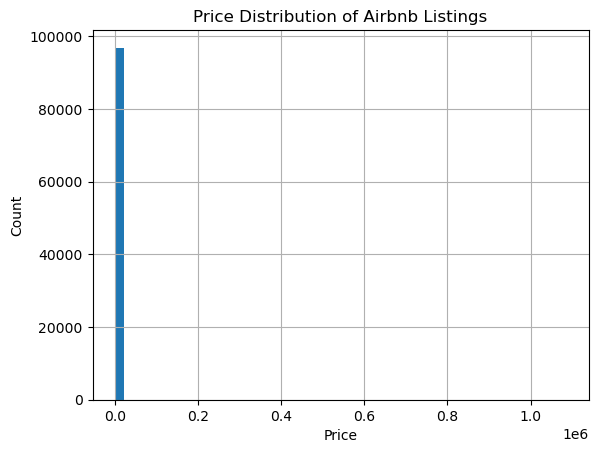

In [6]:
plt.figure()
df["price"].hist(bins=50)
plt.title("Price Distribution of Airbnb Listings")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [7]:
df["room_type"].value_counts()

room_type
Entire home/apt    62907
Private room       33643
Shared room          212
Hotel room           109
Name: count, dtype: int64

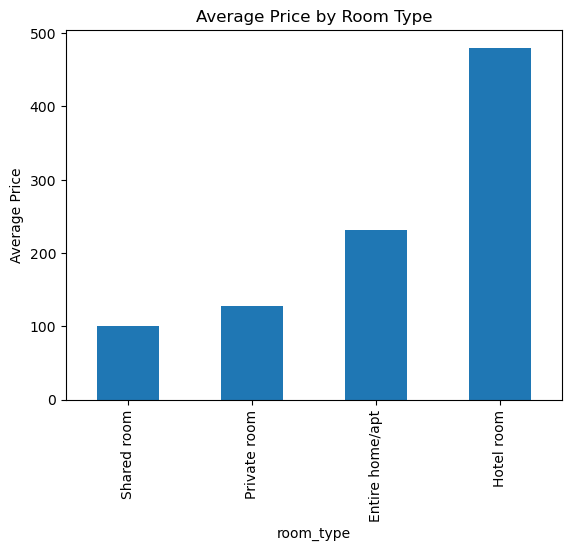

In [8]:
room_price = df.groupby("room_type")["price"].mean().sort_values()

plt.figure()
room_price.plot(kind="bar")
plt.title("Average Price by Room Type")
plt.ylabel("Average Price")
plt.show()

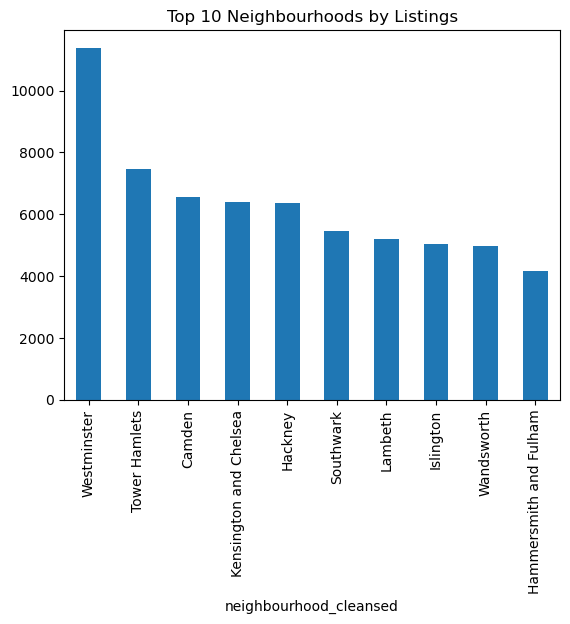

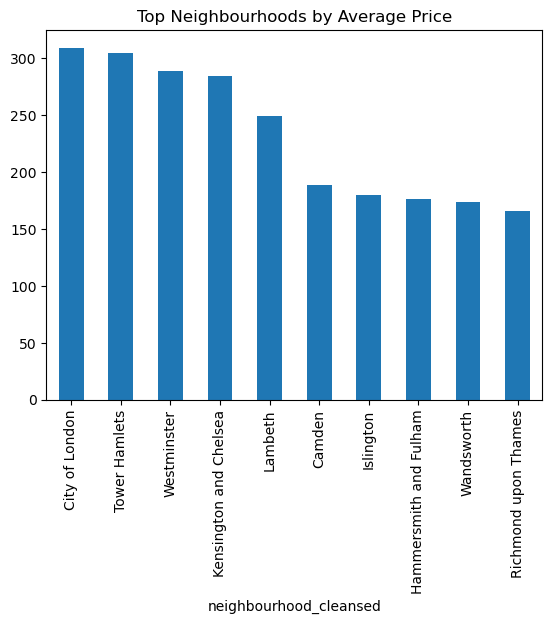

In [9]:
top_neigh = df["neighbourhood_cleansed"].value_counts().head(10)

plt.figure()
top_neigh.plot(kind="bar")
plt.title("Top 10 Neighbourhoods by Listings")
plt.show()
neigh_price = df.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False).head(10)

plt.figure()
neigh_price.plot(kind="bar")
plt.title("Top Neighbourhoods by Average Price")
plt.show()

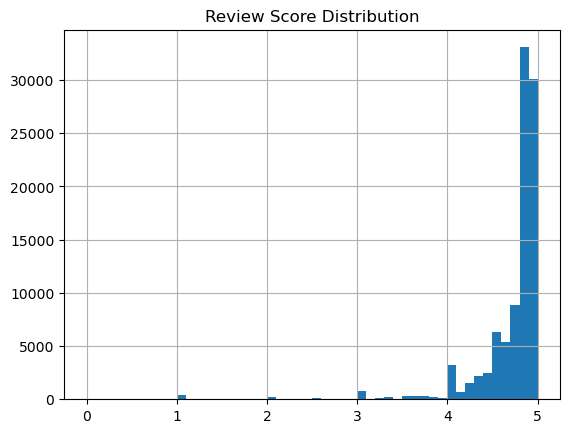

In [12]:
df["review_scores_rating"].describe()
plt.figure()
df["review_scores_rating"].hist(bins=50)
plt.title("Review Score Distribution")
plt.show()

In [19]:
import pandas as pd
import numpy as np

In [24]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()
corr

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
id,1.000000,NaN,0.519273,0.102806,0.100071,0.005368,-0.012842,0.145780,0.130471,0.060430,...,-0.071156,-0.130116,-0.119272,-0.089828,-0.135786,0.139333,0.125994,0.081848,0.028933,0.257086
scrape_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,0.519273,NaN,1.000000,0.087742,0.083690,0.011424,-0.002520,0.061713,0.057823,-0.004902,...,-0.139186,-0.171834,-0.173572,-0.137458,-0.188435,0.074998,0.058406,0.097211,0.000545,0.153453
host_listings_count,0.102806,NaN,0.087742,1.000000,0.902018,0.000677,-0.014350,-0.024019,-0.004536,-0.023272,...,-0.043445,-0.066423,-0.082520,-0.037347,-0.086608,0.749926,0.756882,0.012482,0.000708,-0.025239
host_total_listings_count,0.100071,NaN,0.083690,0.902018,1.000000,0.002973,-0.009046,-0.010554,-0.000131,-0.018570,...,-0.047490,-0.057331,-0.069308,-0.043463,-0.073272,0.681590,0.689275,0.003880,0.004168,-0.029324
latitude,0.005368,NaN,0.011424,0.000677,0.002973,1.000000,0.080839,-0.013868,-0.012307,-0.031405,...,-0.030077,-0.022653,-0.022863,-0.022170,-0.030943,0.011074,0.007621,0.019439,0.001068,0.013857
longitude,-0.012842,NaN,-0.002520,-0.014350,-0.009046,0.080839,1.000000,-0.027024,-0.030971,-0.011818,...,-0.023999,-0.020698,-0.003485,-0.078645,0.000724,-0.041105,-0.040634,-0.003975,-0.009724,-0.031676
accommodates,0.145780,NaN,0.061713,-0.024019,-0.010554,-0.013868,-0.027024,1.000000,0.438098,0.747599,...,-0.035303,-0.027618,-0.033003,-0.018475,-0.059292,0.034921,0.052585,-0.097255,0.042655,0.030291
bathrooms,0.130471,NaN,0.057823,-0.004536,-0.000131,-0.012307,-0.030971,0.438098,1.000000,0.495555,...,0.006011,-0.007438,-0.018336,0.015784,-0.011975,0.042724,0.037533,0.028960,0.031754,0.035785
bedrooms,0.060430,NaN,-0.004902,-0.023272,-0.018570,-0.031405,-0.011818,0.747599,0.495555,1.000000,...,0.003436,0.010338,0.006322,0.003278,0.002380,0.005362,0.023175,-0.094275,-0.021212,-0.047021


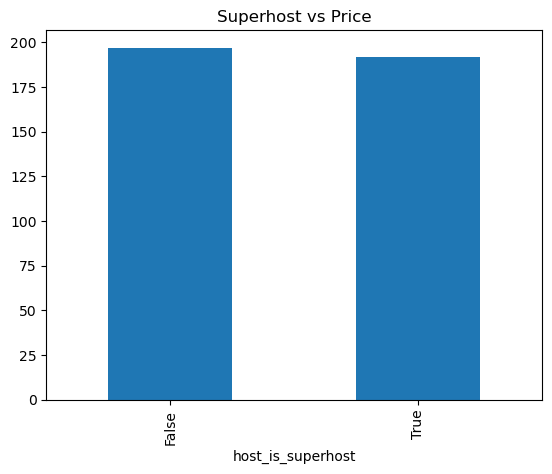

In [27]:
df.groupby("host_is_superhost")["price"].mean()
df.groupby("host_is_superhost")["price"].mean().plot(kind="bar")
plt.title("Superhost vs Price")
plt.show()